# SwissSPAD2 Data Loading

Load, validate, and compare real SwissSPAD2 native BIN and HDF5 acquisitions with PyFLI.

PyFLI supports SwissSPAD2 HDF5 acquisitions (a single `.h5` file or a directory of `.h5` files) and native binary acquisitions (a directory containing matched `topN.bin` and `btmN.bin` files). Both formats are normalized to a three-dimensional `(H, W, T)` fluorescence lifetime image cube.

This notebook walks through:

- loading the native SwissSPAD2 BIN acquisition without corrections,
- validating the decoded detector dimensions and top/bottom stitch,
- inspecting integrated intensity, representative gates, and a pixel trace,
- applying and numerically verifying PyFLI's pile-up correction,
- applying temporal folding and inspecting the detected fold layout,
- loading the corresponding SwissSPAD2 HDF5 acquisition explicitly through the HDF5 I/O path,
- applying pile-up correction to the HDF5 acquisition,
- applying pile-up correction followed by temporal folding to the HDF5 acquisition, and
- comparing the HDF5 raw, pile-up-corrected, and folded traces.

<small>Author - Ismail</small>

In [13]:
## importing the modules required for this work
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

from pyfli.io import Detector

## Configure the acquisition

`DATA_PATH` points to the SwissSPAD2 acquisition used by this notebook. It can be a single HDF5 file, a directory of HDF5 files, or a directory containing matched `topN.bin` / `btmN.bin` files. PyFLI detects the format automatically.

`BIT_SIZE` is the detector bit depth; it defines the dynamic range `2**BIT_SIZE - 1` used by pile-up correction. `EXPECTED_GATE_COUNT` is optional; when it is not `None`, PyFLI validates the decoded gate count against it before any folding.

The folding parameters are optional. When all are `None`, PyFLI detects the excitation period, repeat count, and phase shift automatically. Set `FOLD_REPETITIONS`, `PERIOD_BINS`, and `PHASE_SHIFT` explicitly only when a known acquisition layout must be forced.

In [2]:
# Path to the local SwissSPAD2 acquisition
DATA_PATH = r"D:\downloadsnew\swissspad2_irf_bg\swissspad2_irf_bg\paperirf\bins"

BIT_SIZE = 10
EXPECTED_GATE_COUNT = None

# Optional folding overrides (None means "detect automatically")
FOLD_REPETITIONS = None
PERIOD_BINS = None
PHASE_SHIFT = None
ONSET_LEAD_BINS = None

data_path = Path(DATA_PATH).expanduser().resolve()

if not data_path.exists():
    raise FileNotFoundError(f"SwissSPAD2 data path does not exist: {data_path}")

if BIT_SIZE < 1:
    raise ValueError(f"BIT_SIZE must be positive, got {BIT_SIZE}.")

if EXPECTED_GATE_COUNT is not None and EXPECTED_GATE_COUNT < 1:
    raise ValueError(
        f"EXPECTED_GATE_COUNT must be positive, got {EXPECTED_GATE_COUNT}."
    )

if FOLD_REPETITIONS is not None and FOLD_REPETITIONS < 2:
    raise ValueError("FOLD_REPETITIONS must be at least 2.")

if PERIOD_BINS is not None and PERIOD_BINS < 2:
    raise ValueError("PERIOD_BINS must be at least 2.")
if ONSET_LEAD_BINS is not None and ONSET_LEAD_BINS < 0:
    raise ValueError(f"ONSET_LEAD_BINS must be >= 0, got {ONSET_LEAD_BINS}.")
print(f"Data path: {data_path}")
print(f"Bit size: {BIT_SIZE}")
print(f"Expected gate count: {EXPECTED_GATE_COUNT}")
print(f"Fold repetitions: {FOLD_REPETITIONS}")
print(f"Period bins: {PERIOD_BINS}")
print(f"Phase shift: {PHASE_SHIFT}")
print(f"Onset lead bins: {ONSET_LEAD_BINS}")
if data_path.is_dir():
    hdf5_files = sorted(data_path.glob("*.h5")) + sorted(
        data_path.glob("*.hdf5")
    )
    top_files = sorted(data_path.glob("top*.bin"))
    bottom_files = sorted(data_path.glob("btm*.bin"))

    print(f"HDF5 files: {len(hdf5_files)}")
    print(f"Top BIN files: {len(top_files)}")
    print(f"Bottom BIN files: {len(bottom_files)}")

    for path in hdf5_files + top_files + bottom_files:
        print(path.name)
else:
    print(f"Single file: {data_path.name}")

Data path: D:\downloadsnew\swissspad2_irf_bg\swissspad2_irf_bg\paperirf\bins
Bit size: 10
Expected gate count: None
Fold repetitions: None
Period bins: None
Phase shift: None
Onset lead bins: None
HDF5 files: 0
Top BIN files: 1
Bottom BIN files: 1
top0.bin
btm0.bin


## Load the acquisition

The first load is intentionally performed without pile-up correction, background subtraction, hot-pixel correction, or temporal folding. This preserves the detector output so the acquisition structure can be validated before any processing is applied.

In [3]:
raw_config = {
    "input_format": "auto",
    "bit_depth": BIT_SIZE,
    "pile_up": False,
    "fold": False,
}

if EXPECTED_GATE_COUNT is not None:
    raw_config["ss2_expected_gate_count"] = EXPECTED_GATE_COUNT

loader = Detector(
    data_path=str(data_path),
    bit_size=BIT_SIZE,
)

dataset = loader.SS2(
    name="SwissSPAD2_raw",
    sub_bg=False,
    pile_up=False,
    hot_pixel=False,
    make_hp_map=False,
    config=raw_config,
)

In [4]:
decay = np.asarray(dataset["raw_data"]["decay"])
processing = dataset["metadata"]["processing"]
spad_metadata = processing["spad_metadata"]["decay"]
input_format = processing["input_format"]

if decay.ndim != 3:
    raise RuntimeError(
        f"SwissSPAD2 data must have shape (H, W, T), got {decay.shape}."
    )

if not np.all(np.isfinite(decay)):
    raise RuntimeError(
        "The loaded SwissSPAD2 cube contains non-finite values."
    )

if input_format == "ss2_bin" and decay.shape[:2] != (512, 512):
    raise RuntimeError(
        "Native SwissSPAD2 binary data must decode to a 512 x 512 detector image, "
        f"got {decay.shape[:2]}."
    )

if spad_metadata["pile_up_applied"]:
    raise RuntimeError(
        "The raw acquisition unexpectedly has pile-up correction applied."
    )

if spad_metadata["fold_applied"]:
    raise RuntimeError(
        "The raw acquisition unexpectedly has temporal folding applied."
    )

print(f"Dataset name: {dataset['name']}")
print(f"Source: {dataset['source']}")
print(f"Input format: {input_format}")
print(f"Decay shape: {decay.shape}")
print(f"Decay dtype: {decay.dtype}")
print(f"Minimum count: {np.min(decay)}")
print(f"Maximum count: {np.max(decay)}")
print(f"Total counts: {np.sum(decay, dtype=np.float64):.0f}")

Dataset name: SwissSPAD2_raw
Source: SwissSPAD2
Input format: ss2_bin
Decay shape: (512, 512, 280)
Decay dtype: uint16
Minimum count: 0
Maximum count: 1020
Total counts: 34326177197


## Inspect the integrated intensity

Summing the temporal axis produces a two-dimensional intensity image. This is the first spatial validation of the decoded acquisition and is especially useful for identifying gross detector ordering or stitching errors.

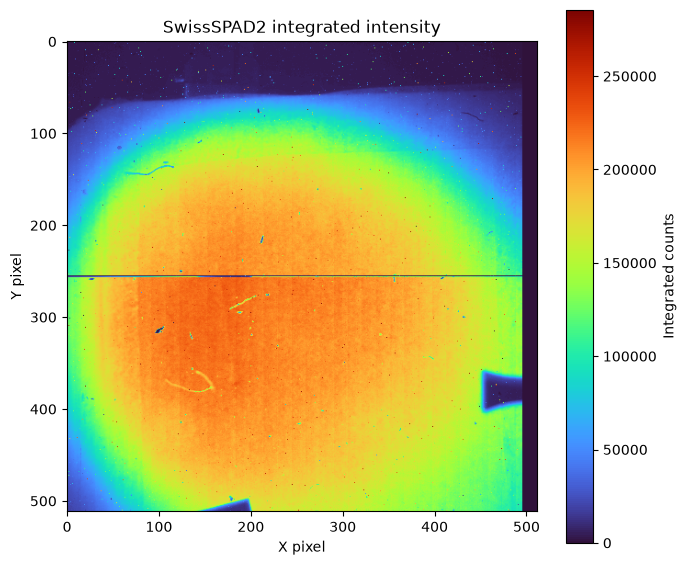

In [5]:
intensity = np.sum(
    decay,
    axis=-1,
    dtype=np.float64,
)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    intensity,
    cmap="turbo",
    origin="upper",
)

fig.colorbar(
    image,
    ax=ax,
    label="Integrated counts",
)

ax.set_title("SwissSPAD2 integrated intensity")
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

fig.tight_layout()
plt.show()

## Inspect the temporal response of a single pixel

A single illuminated pixel is selected at random and its gate trace is plotted. This is the direct equivalent of a pixel readout in the detector's own viewer and gives an unambiguous view of gate ordering and the time-resolved signal. The same selected pixel is retained for the raw, pile-up-corrected, and folded comparisons below.

Selected pixel (row, column): (411, 179)
Pixel min / max count: 562 / 877


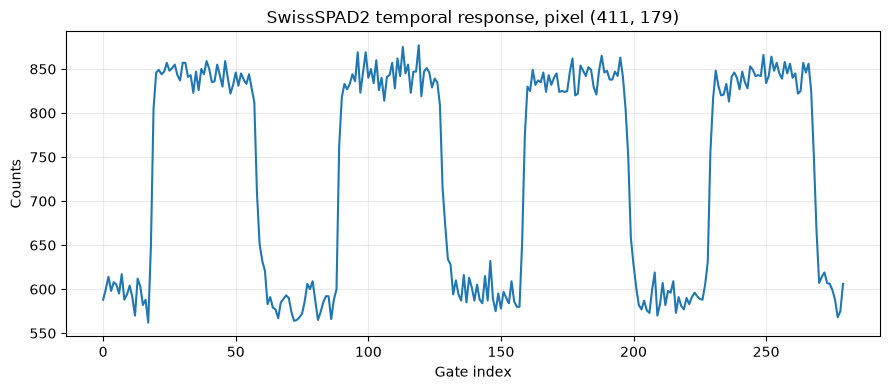

In [6]:
intensity_map = np.sum(decay, axis=-1, dtype=np.float64)
illuminated = intensity_map > np.median(intensity_map)
candidate_rows, candidate_columns = np.nonzero(illuminated)

if candidate_rows.size == 0:
    raise RuntimeError(
        "No pixels above the median integrated intensity were found."
    )

rng = np.random.default_rng()
selected = rng.integers(candidate_rows.size)
pixel_row = int(candidate_rows[selected])
pixel_column = int(candidate_columns[selected])

pixel_trace = decay[
    pixel_row,
    pixel_column,
    :,
].astype(np.float64)

gate_axis = np.arange(decay.shape[-1])

print(
    f"Selected pixel (row, column): "
    f"({pixel_row}, {pixel_column})"
)
print(
    f"Pixel min / max count: "
    f"{pixel_trace.min():.0f} / {pixel_trace.max():.0f}"
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    gate_axis,
    pixel_trace,
)

ax.set_title(
    f"SwissSPAD2 temporal response, "
    f"pixel ({pixel_row}, {pixel_column})"
)
ax.set_xlabel("Gate index")
ax.set_ylabel("Counts")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Inspect representative gates

Several gates distributed across the acquisition are displayed independently. This provides a direct visual check that the spatial image remains physically consistent across the temporal dimension.

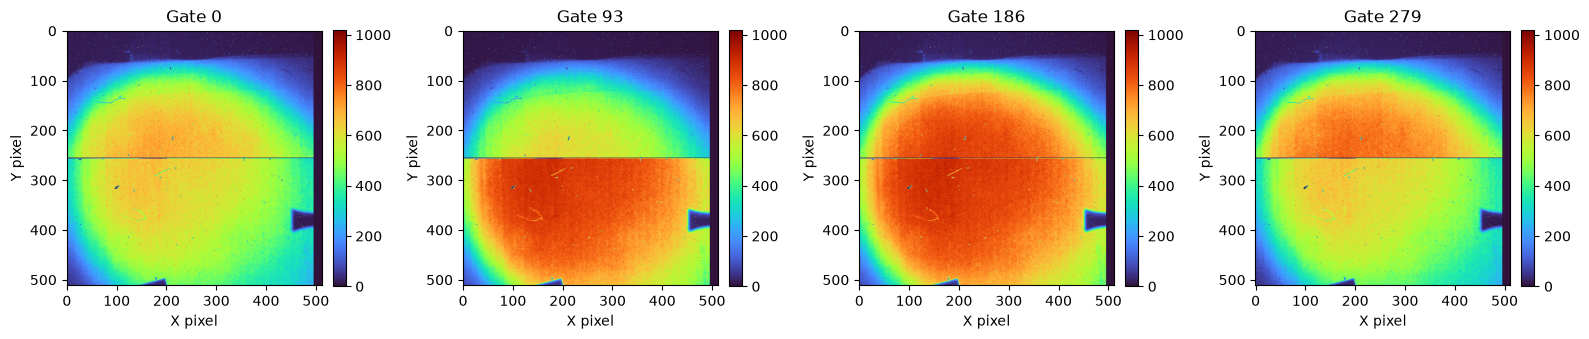

In [7]:
number_of_gate_images = min(
    4,
    decay.shape[-1],
)

gate_indices = np.unique(
    np.linspace(
        0,
        decay.shape[-1] - 1,
        number_of_gate_images,
        dtype=int,
    )
)

fig, axes = plt.subplots(
    1,
    len(gate_indices),
    figsize=(4 * len(gate_indices), 4),
    squeeze=False,
)

for axis, gate_index in zip(
    axes[0],
    gate_indices,
):
    image = axis.imshow(
        decay[..., gate_index],
        cmap="turbo",
        origin="upper",
    )

    axis.set_title(f"Gate {gate_index}")
    axis.set_xlabel("X pixel")
    axis.set_ylabel("Y pixel")

    fig.colorbar(
        image,
        ax=axis,
        fraction=0.046,
        pad=0.04,
    )

fig.tight_layout()
plt.show()

## Review import metadata

PyFLI records the resolved input format, raw and output shapes, detector settings, processing state, and lower-level reader metadata with the loaded dataset.

In [8]:
pprint(
    spad_metadata,
    sort_dicts=False,
)

{'source': {'source_format': 'ss2_bin',
            'bit_depth': 10,
            'chunk_indices': (0,),
            'top_files': ('D:\\downloadsnew\\swissspad2_irf_bg\\swissspad2_irf_bg\\paperirf\\bins\\top0.bin',),
            'bottom_files': ('D:\\downloadsnew\\swissspad2_irf_bg\\swissspad2_irf_bg\\paperirf\\bins\\btm0.bin',),
            'raw_frame_count': 1120,
            'gate_count': 280,
            'half_shape': (256, 512),
            'stitched_shape': (512, 512, 280),
            'column_banks': 4,
            'bank_width': 128,
            'raw_dtype': 'uint8',
            'output_dtype': 'uint16',
            'subframes_per_gate': 4,
            'detector': 'ss2'},
 'detector': 'ss2',
 'input_format': 'ss2_bin',
 'raw_shape': (512, 512, 280),
 'raw_dtype': 'uint16',
 'output_shape': (512, 512, 280),
 'output_dtype': 'uint16',
 'bit_depth': 10,
 'hot_pixel_applied': False,
 'hot_pixel_scope': None,
 'pile_up_applied': False,
 'pile_up_scope': None,
 'sub_bg_applied': False,

## Apply pile-up correction

SwissSPAD2 gates saturate as the per-gate count approaches the digitization ceiling `2**BIT_SIZE - 1`. Pile-up correction inverts the counting statistics with `corrected = -ln(1 - measured / max_counts) * max_counts`, which restores linearity near the ceiling and converts the cube from integer counts to `float32`.

The acquisition is re-loaded with `pile_up=True`, temporal folding remains disabled, and the same pixel selected above is compared before and after correction.

Pile-up applied: True
Dynamic range: 1023
Corrected dtype: float32
Raw pixel max: 877
Corrected pixel max: 1991.7
Raw cube max: 1020
Corrected cube max: 5966.0


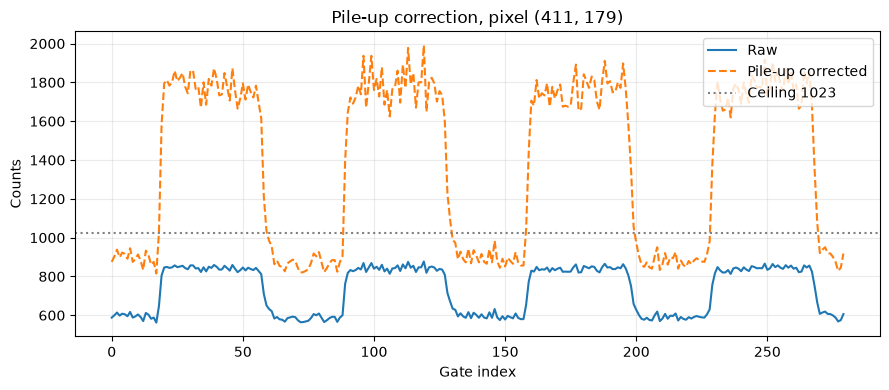

In [9]:
pileup_config = {
    "input_format": "auto",
    "bit_depth": BIT_SIZE,
    "pile_up": True,
    "fold": False,
}

if EXPECTED_GATE_COUNT is not None:
    pileup_config[
        "ss2_expected_gate_count"
    ] = EXPECTED_GATE_COUNT

pileup_dataset = Detector(
    data_path=str(data_path),
    bit_size=BIT_SIZE,
).SS2(
    name="SwissSPAD2_pileup",
    sub_bg=False,
    pile_up=True,
    hot_pixel=False,
    make_hp_map=False,
    config=pileup_config,
)

pileup_decay = np.asarray(
    pileup_dataset["raw_data"]["decay"]
)

pileup_metadata = (
    pileup_dataset[
        "metadata"
    ][
        "processing"
    ][
        "spad_metadata"
    ][
        "decay"
    ]
)

if pileup_decay.shape != decay.shape:
    raise RuntimeError(
        f"Pile-up corrected cube {pileup_decay.shape} "
        f"does not match the raw cube {decay.shape}."
    )

if pileup_decay.dtype != np.float32:
    raise RuntimeError(
        f"Pile-up corrected cube must have float32 dtype, "
        f"got {pileup_decay.dtype}."
    )

if not np.all(
    np.isfinite(pileup_decay)
):
    raise RuntimeError(
        "The pile-up corrected cube contains "
        "non-finite values."
    )

if not pileup_metadata[
    "pile_up_applied"
]:
    raise RuntimeError(
        "Pile-up correction was requested but was "
        "not recorded as applied."
    )

if pileup_metadata[
    "fold_applied"
]:
    raise RuntimeError(
        "Pile-up-only load unexpectedly applied "
        "temporal folding."
    )

max_counts = (
    2**BIT_SIZE - 1
)

pileup_pixel_trace = pileup_decay[
    pixel_row,
    pixel_column,
    :,
].astype(np.float64)

print(
    f"Pile-up applied: "
    f"{pileup_metadata['pile_up_applied']}"
)
print(
    f"Dynamic range: {max_counts}"
)
print(
    f"Corrected dtype: {pileup_decay.dtype}"
)
print(
    f"Raw pixel max: {pixel_trace.max():.0f}"
)
print(
    f"Corrected pixel max: "
    f"{pileup_pixel_trace.max():.1f}"
)
print(
    f"Raw cube max: {np.max(decay)}"
)
print(
    f"Corrected cube max: "
    f"{np.max(pileup_decay):.1f}"
)

fig, ax = plt.subplots(
    figsize=(9, 4)
)

ax.plot(
    gate_axis,
    pixel_trace,
    label="Raw",
)

ax.plot(
    gate_axis,
    pileup_pixel_trace,
    label="Pile-up corrected",
    linestyle="--",
)

ax.axhline(
    max_counts,
    color="gray",
    linestyle=":",
    label=f"Ceiling {max_counts}",
)

ax.set_title(
    f"Pile-up correction, "
    f"pixel ({pixel_row}, {pixel_column})"
)
ax.set_xlabel("Gate index")
ax.set_ylabel("Counts")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Apply temporal folding

A SwissSPAD2 gate sweep usually spans several excitation periods. Folding detects the period length in gates, the number of repeats, and the circular phase shift that places the pulse onset at the start of a period, then aligns and sums the repeats into a single period. This raises the per-gate signal-to-noise ratio and produces the `(H, W, period_bins)` cube expected by the lifetime-analysis workflows.

The acquisition is re-loaded with `pile_up=True` and `fold=True`. PyFLI detects the onset of the signal and starts the folded period a few gates before it (`onset_lead_bins`, 5 % of the period by default) so the complete rising edge and the pre-pulse baseline are kept at the start of the period. Explicit `FOLD_REPETITIONS`, `PERIOD_BINS`, `PHASE_SHIFT`, and `ONSET_LEAD_BINS` values are forwarded only when they are set in the configuration cell.

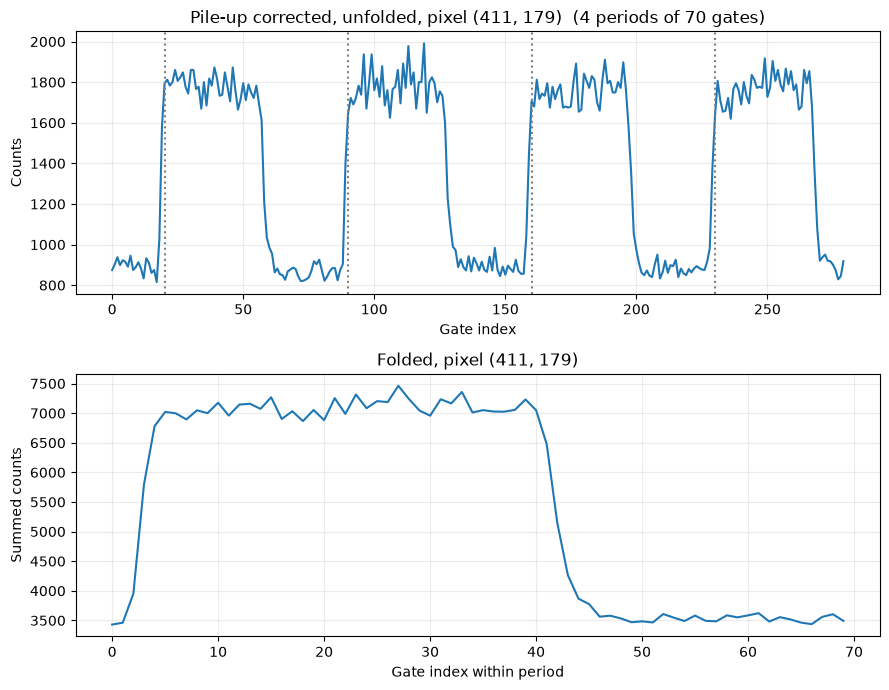

In [12]:
fold_config = {
    "input_format": "auto",
    "bit_depth": BIT_SIZE,
    "pile_up": True,
    "fold": True,
}

folded_dataset = Detector(
    data_path=str(data_path),
    bit_size=BIT_SIZE,
).SS2(
    name="SwissSPAD2_folded",
    sub_bg=False,
    pile_up=True,
    hot_pixel=False,
    make_hp_map=False,
    config=fold_config,
)

folded_decay = np.asarray(
    folded_dataset[
        "raw_data"
    ][
        "decay"
    ]
)

folded_metadata = (
    folded_dataset[
        "metadata"
    ][
        "processing"
    ][
        "spad_metadata"
    ][
        "decay"
    ]
)

fold_layout = folded_metadata[
    "fold"
]

folded_pixel_trace = folded_decay[
    pixel_row,
    pixel_column,
    :,
].astype(np.float64)

folded_gate_axis = np.arange(
    folded_decay.shape[-1]
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 7),
)

axes[0].plot(
    gate_axis,
    pileup_pixel_trace,
)

for position in fold_layout[
    "pulse_positions"
]:
    axes[0].axvline(
        position,
        color="gray",
        linestyle=":",
    )

axes[0].set_title(
    f"Pile-up corrected, unfolded, "
    f"pixel ({pixel_row}, {pixel_column})  "
    f"({fold_layout['repeat_count']} periods "
    f"of {fold_layout['period_bins']} gates)"
)

axes[0].set_xlabel(
    "Gate index"
)
axes[0].set_ylabel(
    "Counts"
)
axes[0].grid(
    alpha=0.25
)

axes[1].plot(
    folded_gate_axis,
    folded_pixel_trace,
)

axes[1].set_title(
    f"Folded, pixel "
    f"({pixel_row}, {pixel_column})"
)
axes[1].set_xlabel(
    "Gate index within period"
)
axes[1].set_ylabel(
    "Summed counts"
)
axes[1].grid(
    alpha=0.25
)

fig.tight_layout()
plt.show()

## Load SwissSPAD2 HDF5 data

SwissSPAD2 HDF5 acquisitions use the same `Detector.SS2` interface as native BIN acquisitions.

This section is intentionally separate from the native BIN example above. It locates the HDF5 acquisition associated with the configured data path, loads it explicitly with `input_format="hdf5"`, applies pile-up correction without folding, then loads it again with pile-up correction followed by temporal folding.

When the HDF5 acquisition contains multiple files, PyFLI applies pile-up correction to each HDF5 cube before combining the files. Folding is applied after correction and uses the detected fold layout recorded in the returned metadata.

HDF5 data path: D:\downloadsnew\swissspad2_irf_bg\swissspad2_irf_bg\paperirf\F8_5V_MW_15Wns_stitched.hdf5
Selected pixel: (172, 266)
Folded shape: (512, 512, 70)
Pile-up applied: True
Fold applied: True
Period bins: 70
Repeat count: 4
Phase shift: -16
Confidence: 0.9914


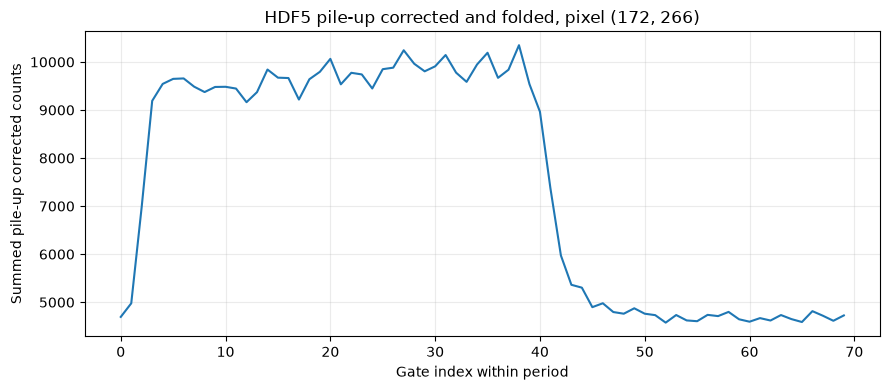

In [19]:
# SwissSPAD2 HDF5 acquisition
hdf5_data_path = Path(
    r"D:\downloadsnew\swissspad2_irf_bg\swissspad2_irf_bg\paperirf\F8_5V_MW_15Wns_stitched.hdf5"
).expanduser().resolve()

if not hdf5_data_path.exists():
    raise FileNotFoundError(
        f"HDF5 file does not exist: {hdf5_data_path}"
    )

print(f"HDF5 data path: {hdf5_data_path}")


# Load HDF5 with pile-up correction followed by temporal folding
hdf5_fold_config = {
    "input_format": "hdf5",
    "bit_depth": BIT_SIZE,
    "pile_up": True,
    "fold": True,
}

if FOLD_REPETITIONS is not None:
    hdf5_fold_config["fold_repetitions"] = FOLD_REPETITIONS

if PERIOD_BINS is not None:
    hdf5_fold_config["period_bins"] = PERIOD_BINS

if PHASE_SHIFT is not None:
    hdf5_fold_config["phase_shift"] = PHASE_SHIFT


hdf5_folded_dataset = Detector(
    data_path=str(hdf5_data_path),
    bit_size=BIT_SIZE,
).SS2(
    name="SwissSPAD2_HDF5_folded",
    sub_bg=False,
    pile_up=True,
    hot_pixel=False,
    make_hp_map=False,
    config=hdf5_fold_config,
)


hdf5_folded_decay = np.asarray(
    hdf5_folded_dataset["raw_data"]["decay"]
)

hdf5_folded_metadata = (
    hdf5_folded_dataset[
        "metadata"
    ][
        "processing"
    ][
        "spad_metadata"
    ][
        "decay"
    ]
)

hdf5_fold_layout = hdf5_folded_metadata["fold"]

if hdf5_fold_layout is None:
    raise RuntimeError(
        "HDF5 folding was requested but no fold layout was returned."
    )

if not hdf5_folded_metadata["pile_up_applied"]:
    raise RuntimeError(
        "HDF5 pile-up correction was requested but was not applied."
    )

if not hdf5_folded_metadata["fold_applied"]:
    raise RuntimeError(
        "HDF5 folding was requested but was not applied."
    )

if hdf5_folded_decay.ndim != 3:
    raise RuntimeError(
        f"Folded HDF5 cube must have shape (H, W, T), "
        f"got {hdf5_folded_decay.shape}."
    )

if not np.all(np.isfinite(hdf5_folded_decay)):
    raise RuntimeError(
        "Folded HDF5 cube contains non-finite values."
    )


# Select one pixel with the strongest temporal variation
hdf5_temporal_variation = np.std(
    hdf5_folded_decay,
    axis=-1,
)

hdf5_pixel_row, hdf5_pixel_column = np.unravel_index(
    np.argmax(hdf5_temporal_variation),
    hdf5_temporal_variation.shape,
)

hdf5_pixel_row = int(hdf5_pixel_row)
hdf5_pixel_column = int(hdf5_pixel_column)


# Extract the folded pixel trace
hdf5_folded_trace = hdf5_folded_decay[
    hdf5_pixel_row,
    hdf5_pixel_column,
    :,
].astype(np.float64)

hdf5_folded_gate_axis = np.arange(
    hdf5_folded_decay.shape[-1]
)


print(
    f"Selected pixel: "
    f"({hdf5_pixel_row}, {hdf5_pixel_column})"
)

print(
    f"Folded shape: "
    f"{hdf5_folded_decay.shape}"
)

print(
    f"Pile-up applied: "
    f"{hdf5_folded_metadata['pile_up_applied']}"
)

print(
    f"Fold applied: "
    f"{hdf5_folded_metadata['fold_applied']}"
)

print(
    f"Period bins: "
    f"{hdf5_fold_layout['period_bins']}"
)

print(
    f"Repeat count: "
    f"{hdf5_fold_layout['repeat_count']}"
)

print(
    f"Phase shift: "
    f"{hdf5_fold_layout['phase_shift']}"
)

print(
    f"Confidence: "
    f"{hdf5_fold_layout['confidence']:.4f}"
)


# Plot one pile-up corrected and folded HDF5 pixel
fig, ax = plt.subplots(
    figsize=(9, 4)
)

ax.plot(
    hdf5_folded_gate_axis,
    hdf5_folded_trace,
)

ax.set_title(
    f"HDF5 pile-up corrected and folded, "
    f"pixel ({hdf5_pixel_row}, {hdf5_pixel_column})"
)

ax.set_xlabel(
    "Gate index within period"
)

ax.set_ylabel(
    "Summed pile-up corrected counts"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()
plt.show()

## Summary

The SwissSPAD2 acquisition has been loaded three ways through the same `Detector.SS2` call: unchanged, with pile-up correction, and with pile-up correction followed by temporal folding. Each load returns the standard PyFLI dataset structure, and the processing metadata records the resolved input format, bit depth, correction state, and the detected fold layout.

The next example builds on this with background subtraction, hot-pixel correction, an analysis mask, and an instrument response acquisition for HDF5 folder data.